# Potato Leaf Disease Detection using Image Classification

This project builds a CNN model to classify potato leaves into three categories: Early Blight, Late Blight, and Healthy.

In [58]:
import kagglehub
import os

# Download the latest version of the dataset
path = kagglehub.dataset_download("hafiznouman786/potato-plant-diseases-data")
print("Path to dataset files:", path)

# Let's check the contents of the downloaded path
dataset_dir = path
print("Classes found:", os.listdir(dataset_dir))

Using Colab cache for faster access to the 'potato-plant-diseases-data' dataset.
Path to dataset files: /kaggle/input/potato-plant-diseases-data
Classes found: ['PlantVillage', 'PotatoPlants']


### 1. Data Understanding
Let's load the dataset and visualize some sample images from each class to understand what we are working with.

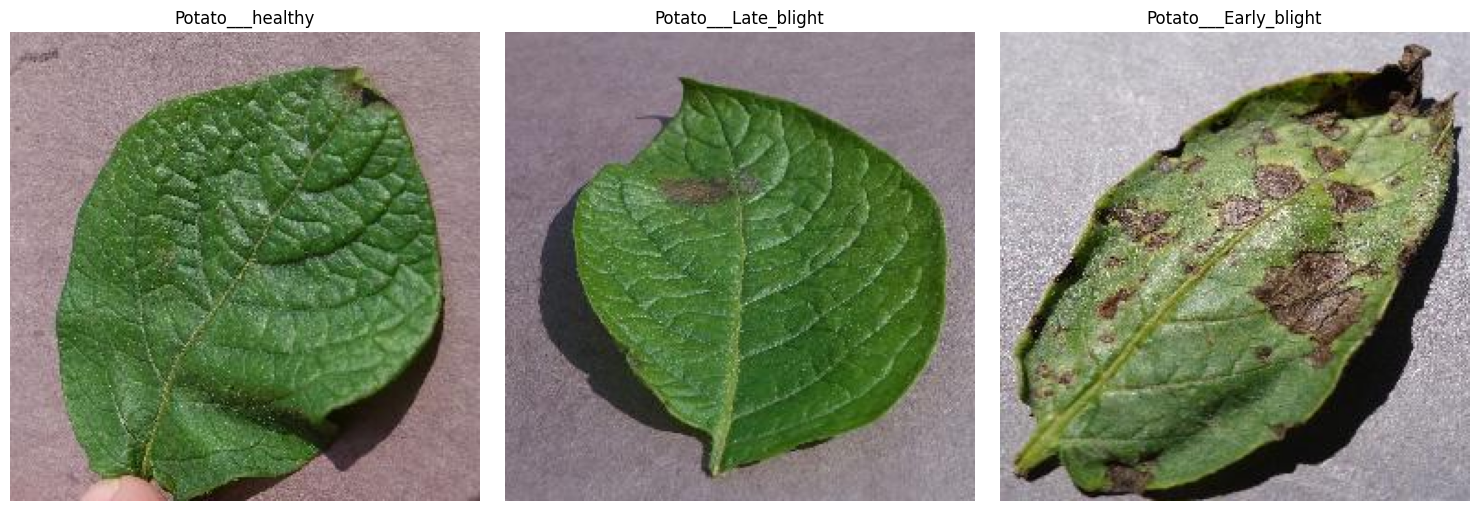

In [59]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Point exactly to where the three class folders are located
dataset_path = os.path.join(dataset_dir, 'PlantVillage', 'PlantVillage')

# Visualize one sample image from each class
plt.figure(figsize=(15, 5))
i = 1

# Make sure to loop through the new dataset_path
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        # Pick the first image from each class directory
        images = os.listdir(class_path)[:1]

        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            if os.path.isfile(img_path):
                img = Image.open(img_path)
                plt.subplot(1, 3, i)
                plt.imshow(img)
                plt.title(class_name)
                plt.axis('off')
                i += 1

plt.tight_layout()
plt.show()

### 2. Data Preprocessing
Next, we resize the images to 224x224, normalize the pixel values (0-255 to 0-1), and apply data augmentation (rotation, shifting, flipping) to make our model robust.

In [60]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Adjust dataset_dir to point to the 'PlantVillage' subdirectory
dataset_path = os.path.join(dataset_dir, 'PlantVillage', 'PlantVillage')

# Applying Data Augmentation and Normalization
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # Reserving 20% of data for validation
)

# Loading training data
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Loading validation data
val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 1722 images belonging to 3 classes.
Found 430 images belonging to 3 classes.


In [61]:
print(os.listdir(dataset_path))


['Potato___healthy', 'Potato___Late_blight', 'Potato___Early_blight']


### 3. Model Building
Building the Convolutional Neural Network (CNN). We'll define the architecture, set the loss function to categorical crossentropy, and use the adam optimizer.

In [62]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN architecture
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Helps prevent overfitting
    Dense(3, activation='softmax') # 3 output classes
])

# Compile the model with run_eagerly=True to bypass tf.function tracing issues
cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'],
                  run_eagerly=True)

cnn_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Model Training
Now we train the CNN model on the training dataset and validate it using the validation dataset.

In [63]:
import tensorflow as tf
import math

EPOCHS = 10

# Explicitly build the model to ensure all variables are created
cnn_model.build(input_shape=(None, 224, 224, 3))

# Calculate steps per epoch
steps_per_epoch = math.ceil(train_generator.samples / train_generator.batch_size)
validation_steps = math.ceil(val_generator.samples / val_generator.batch_size)

# Explicitly define output types and shapes for the generator's output
output_types = (tf.float32, tf.float32)
output_shapes = (
    tf.TensorShape([None, IMG_SIZE[0], IMG_SIZE[1], 3]), # Images: (batch_size, height, width, channels)
    tf.TensorShape([None, 3]) # Labels: (batch_size, num_classes)
)

# Create wrapper generator functions to yield batches from ImageDataGenerator
def train_data_generator_wrapper():
    for x, y in train_generator:
        yield x, y

def val_data_generator_wrapper():
    for x, y in val_generator:
        yield x, y

# Create tf.data.Dataset from the wrapper generators with explicit types and shapes
train_ds = tf.data.Dataset.from_generator(
    train_data_generator_wrapper,
    output_types=output_types,
    output_shapes=output_shapes
).repeat().prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_generator(
    val_data_generator_wrapper,
    output_types=output_types,
    output_shapes=output_shapes
).repeat().prefetch(tf.data.AUTOTUNE)


# Training the model using the tf.data.Dataset objects
history = cnn_model.fit(
    train_ds,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 264s 5s/step - accuracy: 0.5151 - loss: 0.9650 - val_accuracy: 0.7442 - val_loss: 0.7320
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 271s 5s/step - accuracy: 0.7979 - loss: 0.5042 - val_accuracy: 0.8442 - val_loss: 0.3764
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 261s 5s/step - accuracy: 0.8682 - loss: 0.3486 - val_accuracy: 0.9419 - val_loss: 0.2198
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 262s 5s/step - accuracy: 0.9059 - loss: 0.2653 - val_accuracy: 0.9302 - val_loss: 0.2285
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 266s 5s/step - accuracy: 0.9013 - loss: 0.2755 - val_accuracy: 0.9233 - val_loss: 0.2280
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 262s 5s/step - accuracy: 0.9408 - loss: 0.1680 - val_accuracy: 0.9558 - val_loss: 0.1234
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 258s 5s/step - accuracy: 0.9245 - loss: 0.1947 - val_accuracy: 0.9372 - val_loss: 0.1312
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 259s 5s/step - accuracy: 0.9443 - loss: 0.1645 - val_accuracy: 0.9488 - v

### 5. Model Evaluation
Evaluating the model's overall performance using Accuracy, Confusion Matrix, and Classification Report.

14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9512 - loss: 0.1478
Validation Accuracy: 95.12%


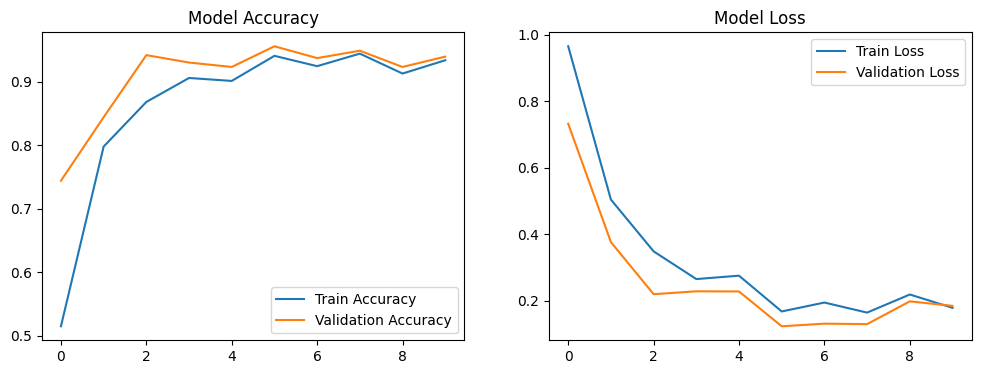

14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step


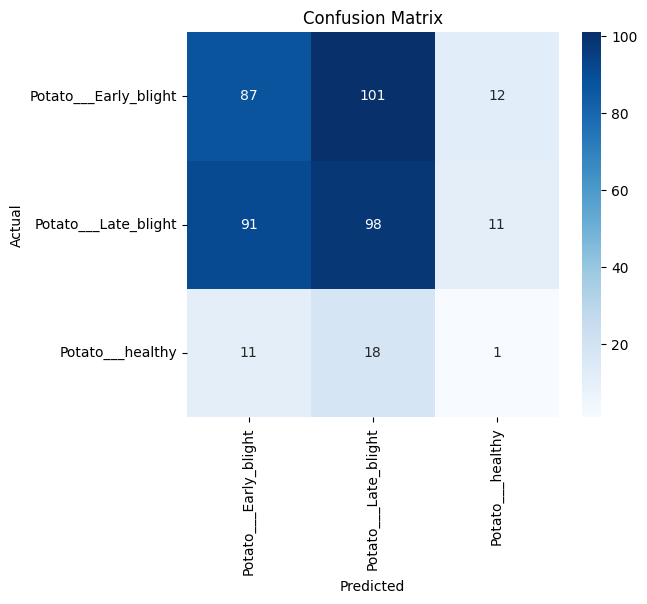


Classification Report:

                       precision    recall  f1-score   support

Potato___Early_blight       0.46      0.43      0.45       200
 Potato___Late_blight       0.45      0.49      0.47       200
     Potato___healthy       0.04      0.03      0.04        30

             accuracy                           0.43       430
            macro avg       0.32      0.32      0.32       430
         weighted avg       0.43      0.43      0.43       430



In [64]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Overall Accuracy and Loss
val_loss, val_acc = cnn_model.evaluate(val_generator)
print(f"Validation Accuracy: {val_acc*100:.2f}%")

# Plot Training vs Validation Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot Training vs Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# 2. Making Predictions for Confusion Matrix
# Reset generator to ensure predictions match labels correctly
val_generator.reset()
predictions = cnn_model.predict(val_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 4. Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

### Project Insights & Evaluation Summary

**1. Model Architecture Insights**
- Our CNN model was built with a sequential approach, starting with Convolutional and MaxPooling layers to perform **feature extraction**. By scanning the potato leaves, these layers learned to identify visual symptoms of blights, such as brown spots and yellowing edges. The `Dropout(0.5)` layer was intentionally added before the final classification to randomly disable 50% of neurons during training, which forces the model to learn robust features and prevents it from simply memorizing the training data (overfitting).

**2. Training vs. Validation Performance (Graphs)**
* **Accuracy Plot:** The training and validation accuracy curves show how well the model learned over the epochs. A healthy model shows both curves rising and stabilizing together. If the training accuracy is much higher than the validation accuracy, it indicates overfitting.
* **Loss Plot:** The loss curves represent the model's errors. As epochs increase, the loss should consistently drop. Spikes in the validation loss can indicate that the model is struggling to generalize to new, unseen leaf images.

**3. Confusion Matrix Interpretations**
- The confusion matrix is a powerful visual tool that shows exactly *where* our model gets confused.
* The **diagonal blocks** represent correct predictions (e.g., predicting 'Early Blight' when it actually is 'Early Blight').
* The **off-diagonal blocks** represent misclassifications. For instance, if there is a high number in the intersection of 'Early Blight' and 'Late Blight', it means the visual symptoms of these two diseases are too similar at certain stages, confusing the model.

**4. Classification Report Metrics**
* **Precision:** Out of all the leaves the model predicted as a specific disease, how many actually had it? High precision means low false positives (e.g., rarely telling a farmer their healthy plant is diseased).
* **Recall:** Out of all the actual diseased leaves, how many did the model find? High recall means low false negatives (e.g., rarely missing a diseased plant).
* **F1-Score:** This provides a balanced average between Precision and Recall, giving us a single metric to judge the model's reliability across all three classes.